# 8-1 단순해도 깊어서 좋은 VGGNet

본 노트북은 8-1 절 본문의 [코드 8-1], [코드 8-2] 예제와, 본문이 "깃허브 노트북에서 확인" 으로 안내한 MiniAlexNet 모델 정의·학습 코드, 그리고 [표 8-1], [표 8-2] 의 비교 결과를 포함한다.

다루는 내용
- 베이스라인 데이터로더(CIFAR-10, 데이터 증강 미적용)
- 베이스라인 모델 `MiniAlexNet` (5-3 절 모델의 8장 별명)
- `[코드 8-1]` VGGNet 의 아이디어를 차용한 `MiniVGGNet` 클래스
- `[코드 8-2]` `torchinfo.summary()` 로 모델 구조 정보 확인
- `[표 8-1]`·`[표 8-2]` 두 모델의 파라미터·학습 결과 비교

참고 8-1절 ~ 8-3절 리뷰

1. 재현성 수정 확인 — 의도대로 반영됨
세 노트북 모두 다음이 일관되게 적용되어 있습니다.

항목	확인 위치
common.set_seed(SEED, deterministic=True) — 노트북 최상단	08-01 [5], 08-02 [5], 08-03 [5]
모델 학습 셀마다 시드 재고정	08-01 [18]·[20], 08-02 [21], 08-03 [29]
DataLoader(generator=...) 제거 → 전역 RNG로 통일	08-01 [7], 08-02 [8], 08-03 [15]
train_evaluate_loader를 shuffle=False로 분리	세 노트북 모두
훈련 정확도 측정에 증강 없는 train_evaluate_set 사용	08-01 [19]·[21], 08-02 [22], 08-03 [30]
증강 전 MiniAlexNet이 48~87 에포크로 흔들리던 문제는 학습 셀 단위 시드 고정으로 원인이 제거되었고, 저장된 결과(최적 98 에포크)도 EPOCHS=100이었다면 예산 소진으로 끝났을 값이라 200으로 올린 판단이 맞습니다.

남은 재현성 구멍(경미): 08-02 [26]·[34]·[37]과 08-03 [9]·[11]·[36]은 여전히 torch.manual_seed(SEED)만 호출합니다. 해당 셀은 torch RNG만 사용하므로 결과에 영향은 없지만, "시드 고정은 common.set_seed()로 한다"는 규칙이 노트북 안에서 두 가지로 갈립니다. common.set_seed(SEED)로 통일을 권합니다.

2. 실질적 위험 (우선순위 순)
🔴 2-1. 08-02 [34]가 학습 완료된 model_vggbn을 덮어씀

# [21] 학습
model_vggbn = MiniVGGNetBN(); model_vggbn.to(device)
log_vggbn = train_with_early_stopping(...)
# [22] 평가 — 여기까지는 정상

# [34] 코드 8-10
torch.manual_seed(SEED)
model_vggbn = MiniVGGNetBN()      # ← 학습된 모델을 미학습 CPU 모델로 대체
셀 34 실행 후 독자가 셀 22로 되돌아가면 미학습 모델(정확도 ≈10%)을 평가하게 됩니다. 게다가 셀 34의 모델은 .to(device)가 없어 GPU 환경에서 셀 22 재실행 시 RuntimeError: Expected all tensors to be on the same device가 납니다. 저장된 출력은 순차 실행 결과라 정상이지만, 재실행 함정이 남아 있습니다.


# 권장: 훅 검사용 모델은 이름을 분리
model_hook = MiniVGGNetBN()
conv_layers = [model_hook.features[0][0], ...]
같은 이유로 셀 26의 model = MiniVGGNetBN()도 이름이 지나치게 일반적입니다(model_hook_bn 등).

🔴 2-2. EPOCHS 값이 노트북마다 다름 — 표 8-8 비교 조건 불일치
08-01 [17] EPOCHS = 200
08-02 [18] EPOCHS = 200
08-03 [27] EPOCHS = 100
표 8-8은 MiniVGGNetBN(예산 200, 최적 29)과 MiniResNet(예산 100, 최적 23)을 나란히 놓습니다. 조기 종료가 둘 다 100 이전에 걸려 저장된 수치 자체는 유효하지만, 비교표를 만드는 두 모델의 학습 설정이 다른 상태입니다. 08-03도 200으로 맞추는 편이 안전합니다(재실행 시 ResNet이 늦게 수렴해도 예산에 잘리지 않음).

🟠 2-3. 비교표의 베이스라인이 노트북에서 재현되지 않음
표 8-3(MiniVGGNet vs MiniVGGNetBN): 08-02 [10]에 MiniVGGNet 클래스는 있지만 학습하지 않습니다. 불러오기 코드 [20]은 전부 주석 처리.
표 8-8(MiniVGGNetBN vs MiniResNet): 08-03 [23] 클래스 정의, [28] 불러오기가 모두 주석 처리 → MiniVGGNetBN이 존재하지 않습니다.
즉 독자가 8-2절 노트북만 실행하면 표 8-3의 절반, 8-3절 노트북만 실행하면 표 8-8의 절반만 얻습니다. 세 가지 중 하나로 정리가 필요합니다.

마크다운 셀에 "베이스라인 수치는 8-1(8-2)절 노트북 결과" 라고 명시 — 가장 저비용
주석 처리된 체크포인트 저장/불러오기를 되살림 — 가장 깔끔하나 checkpoints/ 관리 필요
각 노트북에서 베이스라인도 재학습 — 시간 비용 큼(비권장)
🟠 2-4. 08-03 [35] StackedResBlock의 실제 합성곱 수가 라벨과 다름

num_res_blocks = (num_convs - 1) // 2
num_convs=12 → 블록 5개(합성곱 10) + 첫 합성곱 1 = 11개. 96 → 95개, 384 → 383개입니다. 반면 [7] StackedConvBN은 num_blocks가 곧 합성곱 수라 정확합니다. 그림 8-6의 x축 최댓값이 383으로 찍히므로, 캡션·본문에서 "384 합성곱"이라 부르면 그래프와 어긋납니다.

또한 그림 8-4는 12/48/96, 그림 8-6은 12/96/384로 비교 축이 다릅니다. 잔차 학습의 효과를 더 깊은 구간까지 보이려는 의도는 이해되지만, 두 그림을 나란히 놓고 읽는 독자는 96 지점만 공통이라 대응이 어렵습니다. 최소한 96을 공통 기준점으로 삼는다는 안내가 본문에 있으면 좋겠습니다.

🟡 2-5. 08-03 [9] measure_similarity의 배치 크기 2 조건

# 학습 모드의 배치 정규화가 배치 단위 통계로 정규화하므로, 학습에서
# 배치마다 입력이 달라지는 상황과 동일한 조건이 된다.
model.train()
outputs = model(torch.cat([x_a, x_b], dim=0))
주석의 "동일한 조건"은 다소 강한 단언입니다. 실제 학습은 배치 128이고, 여기는 배치 2입니다. 배치가 2면 BN 통계가 두 샘플에 극단적으로 종속되므로 표 8-7의 96 합성곱 코사인 0.400111은 실제 학습보다 훨씬 과장된 값입니다. 현상의 방향(깊어질수록 입력 미세 차이가 증폭)은 옳지만, 주석을 "배치 통계에 대한 의존을 극단적으로 드러내는 조건" 정도로 낮추는 편이 정확합니다.

🟡 2-6. 08-02 [28] 평가 모드 출력의 해석
저장된 출력:


학습 모드:  0.02(0.32) -> 0.00(1.00)
평가 모드:  0.02(0.33) -> 0.02(0.39)
평가 모드의 표준편차 0.39는 "이동 평균을 쓰기 때문"만으로는 설명이 부족합니다. 미학습 모델을 5배치만 통과시켜 running stats가 초깃값(mean 0, var 1)에 가깝게 남은 상태라 정규화가 사실상 거의 작동하지 않은 값입니다. 본문이 이 수치를 "학습/평가 모드의 동작 차이"로만 설명하고 있다면, 조건(미학습·5배치)을 한 줄 덧붙여야 독자가 잘못된 일반화를 하지 않습니다.

3. 마크다운 ↔ 코드 주석 불일치
위치	현재	문제
08-01 [6] MD	"데이터 증강은 적용하지 않은 데이터로더를 사용한다"	사실과 정반대. [7]은 RandomCrop+RandomHorizontalFlip 적용
08-01 [7] 주석	"5-3 절과 동일"	증강이 추가되어 5-3절과 다름
08-02 [6] MD / [8] 주석	MD "8-1 절과 동일" ↔ 주석 "5-3 절과 동일, 데이터 증강 적용"	서로 어긋남. "8-1 절과 동일"이 맞음
08-03 [13] MD / [15] 주석	MD "8-1, 8-2 절과 동일" ↔ 주석 "5-3 절과 동일"	동일 문제
세 노트북의 로더 셀 주석을 # 참고 - CIFAR-10 데이터로더 (8-1 절과 동일, 데이터 증강 적용)으로 통일하면 정리됩니다.

4. 죽은 코드 / 작업 잔재
리뷰 대상 구간에 주석·문자열로 비활성화된 코드가 상당량 남아 있습니다. 저장소 공개본 기준으로는 모두 삭제 대상입니다.

08-01

[11], [13] # 수정 있음 (추후 삭제) 마커 — 편집용 마커가 그대로 남음
[17] 주석 처리된 헬퍼 블록
08-02

[7] 전체가 삼중 따옴표 문자열로 감싼 옛 로더(1,202자) — 실행은 되지만 문자열 리터럴이 출력에 그대로 찍힙니다(저장된 출력 확인). 셀 자체를 삭제해야 합니다.
[17] 학습 함수 3개의 주석 처리된 사본 — [16]과 중복
[18] 주석 처리된 collect_result / print_result_table
[20] 주석 처리된 체크포인트 로딩
[28] #for inputs, labels in train_loader: 잔재
[10]과 [36]이 ConvBlock/MiniAlexNet/MiniVGGNet을 완전히 중복 정의 — [36]의 정의가 최종 유효. 둘 중 하나 제거
[18]과 [34]에서 criterion 중복 정의
08-03 — 가장 심함

[5] 주석 처리된 옛 import·시드 블록
[14] 삼중 따옴표 옛 로더(1,202자)와 [16] 주석 처리된 또 다른 옛 로더 — 같은 죽은 코드가 두 벌
[23] 주석 처리된 MiniVGGNetBN 클래스
[26] 주석 처리된 학습 함수 사본(2,685자) — [25]와 중복
[27] 주석 처리된 헬퍼, [28] 주석 로딩, [31]·[33] 주석
[29] 학습 셀 하단에 옛 학습 코드가 주석으로 통째 남음
5. 컨벤션 (공통코드컨벤션 기준)
불필요한 f 접두: 08-01 [19]·[21], 08-02 [22], 08-03 [30]의 print(f'MiniXXX 모델 평가(평가 데이터셋)') — 치환이 없는 f-string
후행 공백: 08-02 [16]·[21], 08-03 [18]·[20]·[25]·[29] (model.to(device) 뒤 다수, load_state_dict(...) 등)
79자 초과: 로더 셀의 train_set, _ = random_split(train_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED)) (세 노트북 공통, 약 115자), 평가 셀의 train_loss, train_acc = evaluate(model_xxx, train_evaluate_loader, criterion, device) (약 88자)
08-03 [18] nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, — 줄 끝 후행 공백 후 개행(2곳)
6. 메모리 관점 (WSL 고갈 이슈)
train_full + valid_full + test_set으로 CIFAR-10 배열이 3벌 상주합니다. 훈련 5만 + 훈련 5만 + 평가 1만 = 약 184MB(uint8 기준). 세 노트북을 동시에 열어두면 3배가 됩니다. 증강/비증강 데이터셋을 모두 필요로 하는 현재 설계상 불가피하나, "노트북은 절 단위로 하나씩 열고 커널을 종료한 뒤 다음 절로" 라는 안내가 있으면 좋겠습니다.
copy.deepcopy(model.state_dict())가 GPU 텐서를 GPU에 복사합니다. 모델이 작아(≈0.5~2MB) 8장에서는 문제되지 않지만, 관례적으로는 {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}가 안전합니다. 다만 입문서 코드로는 현재 형태가 읽기 쉬우므로 바꾸지 않는 쪽을 권합니다.
num_workers를 지정하지 않아(기본 0) 워커 프로세스에 의한 메모리 증폭은 없습니다. 이 선택은 유지가 맞습니다.
7. 저장된 학습 결과 (증강 적용 후)
모델	최적 에포크	훈련 손실	검증 손실	훈련 정확도	평가 정확도
MiniAlexNet	98 / 200	0.5284	0.6497	81.61%	77.55%
MiniVGGNet	43 / 200	0.3000	0.4841	89.44%	83.38%
MiniVGGNetBN	29 / 200	0.1917	0.3973	93.19%	86.27%
MiniResNet	23 / 100	0.2714	0.4481	90.47%	84.79%
BN이 MiniVGGNet 대비 수렴 1.5배 빠르고 +2.89%p — 8-2절 메시지가 수치로 잘 뒷받침됩니다.
MiniResNet은 MiniVGGNetBN보다 1.48%p 낮지만 파라미터는 절반(299,530 vs 551,018), 수렴은 가장 빠름(23 에포크). 앞서 합의한 "파라미터가 절반인데도 거의 비슷한 결과" 프레이밍과 정확히 맞습니다.
MiniAlexNet은 훈련 81.61%로 여전히 과소적합 구간 — 증강을 얹었을 때 용량 부족이 드러나는 좋은 대비입니다.
조치 요약
반드시 (출판/공개 전)

08-02 [34] model_vggbn 이름 분리 (재실행 시 오평가·device 오류)
08-03 EPOCHS = 100 → 200 (표 8-8 비교 조건 통일)
08-01 [6] 마크다운 "증강 적용하지 않은" → "증강을 적용한" (사실 오류)
08-03 [35] 실제 합성곱 수(11/95/383)와 라벨(12/96/384) 정합 — 캡션·본문 확인
표 8-3 / 표 8-8 베이스라인 출처 안내 추가
권장
6. 죽은 코드 일괄 제거 (특히 08-02 [7], 08-03 [14]·[16]·[26])
7. 로더 셀 주석 "5-3 절과 동일" → "8-1 절과 동일"로 통일
8. torch.manual_seed(SEED) → common.set_seed(SEED) 통일
9. 08-03 [9] 주석의 "동일한 조건" 완화, 08-02 [28] 평가 모드 수치 조건 명시

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torch, numpy, matplotlib, torchvision, torchinfo 는 기본 의존성으로 README 에서 안내한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q numpy torch torchinfo torchvision

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED, deterministic=True)
device = common.get_device()

CUDA를 사용합니다.


## 참고 - 베이스라인 데이터로더 (CIFAR-10)

8장의 모든 모델은 5-3 절과 같은 환경에서 학습한다. 단, 모델 구조 비교에 집중하기 위해 데이터 증강은 적용하지 않은 데이터로더를 사용한다.

In [4]:
# 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 적용)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터 변환 객체
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)

# 검증, 평가 데이터셋 데이터 변환 객체 (증강 없음)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 훈련 데이터셋 데이터 변환 객체 (증강 추가)
train_transform = transforms.Compose([
    # 4 픽셀 패딩 후 32x32 크기로 무작위 자르기
    transforms.RandomCrop(32, padding=4),
    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 데이터셋 생성
TRAIN_SIZE, VALID_SIZE = 40000, 10000       # 훈련/검증 데이터셋의 크기

# 같은 데이터셋으로 증강 변환 적용/미적용 데이터셋을 생성

# 증강 변환 적용: 훈련용으로 사용
train_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=train_transform,
)
# 증강 변환 미적용: 검증, 평가용으로 사용
valid_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=transform,
)

test_set = datasets.CIFAR10(
    root=data_root, train=False,
    download=True, transform=transform,
)

# 같은 기준으로 train_full과 valid_full을 분할해 훈련 데이터셋과 검증 데이터셋 생성
train_set, _ = random_split(train_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))
# train_evaluate_set: 평가 시에는 증강 변환을 하지 않은 데이터셋 적용이 필요
train_evaluate_set, valid_set = random_split(valid_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))

# 배치 크기 128인 데이터로더 생성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
train_evaluate_loader = DataLoader(train_evaluate_set, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련/검증/평가 데이터셋: '
      f'{len(train_set)}/{len(valid_set)}/{len(test_set)}')

훈련/검증/평가 데이터셋: 40000/10000/10000


## 참고 - 베이스라인 모델 MiniAlexNet

5-3 절의 `CIFAR10ConvClassifier`([코드 5-10]) 와 같은 구조를, 8장의 개선 모델과 비교하기 위해 이름만 `MiniAlexNet` 으로 바꿔 사용한다. 5x5 필터로 수용 영역을 빠르게 넓히고 3x3 필터로 특징을 조합하는 AlexNet 의 전략을 담았다.

In [5]:
# 참고 - MiniAlexNet 클래스
# 코드 5-17의 CIFAR10ConvClassifier 클래스와 같음 (드롭아웃 계층 적용)

import torch.nn as nn

# ConvBlock: 합성곱, ReLU 활성화 함수, 최대 풀링으로 구성된 합성곱 블록
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.conv_block(x)

# MiniAlexNet: AlexNet 전략을 차용한 CIFAR-10 분류기
# 큰 합성곱 필터를 앞 부분에 배치해 수용 영역을 빠르게 확장하는 합성곱 모델
class MiniAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 5x5 필터로 수용 영역을 빠르게 확장
        self.conv_block_1 = ConvBlock(
            in_channels=3, out_channels=16,
            kernel_size=5, stride=1, padding=2,
        )                                   # (3, 32, 32) -> (16, 16, 16)
        # 3x3 필터로 특징 추출
        self.conv_block_2 = ConvBlock(
            in_channels=16, out_channels=32,
            kernel_size=3, stride=1, padding=1,
        )                                   # (16, 16, 16) -> (32, 8, 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (32, 8, 8) -> (32 * 8 * 8,)
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

## [코드 8-1] VGGNet 의 아이디어를 차용한 MiniVGGNet 클래스

3x3 크기의 작은 필터만 사용하는 6개의 합성곱 계층으로 구성한다. 합성곱 계층 두 개를 지날 때마다 최대 풀링 계층을 배치해 특징 지도의 크기를 줄여 나간다.

In [6]:
###############################################################################
# 코드 8-1 - VGGNet의 아이디어를 차용한 MiniVGGNet 클래스
###############################################################################

# MiniVGGNet: VGGNet의 구조를 가진 합성곱 신경망 모델(CIFAR-10 데이터셋 분류)
#     특징 추출기: (3x3 필터 합성곱 -> 3x3 필터 합성곱 -> 최대 풀링) * 3
#     분류기: 완전 연결 계층
class MiniVGGNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수 (내부 함수)
        def vgg_block(in_channels, out_channels):
            # VGGNet의 핵심 - 3x3 합성곱 두 번 + 풀링으로 축소
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        # 특징 추출기: VGG 블록을 반복해 배치
        self.features = nn.Sequential(
            vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
            vgg_block(32, 64),              #              -> (64, 8, 8)
            vgg_block(64, 128),             #              -> (128, 4, 4)
        )
        # 분류기: 특징 추출기가 추출한 특징을 사용해 분류
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (128, 4, 4)  -> (128 * 4 * 4,)
            nn.Linear(128 * 4 * 4, 128),    #              -> (128,)
            nn.ReLU(),
            nn.Dropout(p=0.5),              # 드롭아웃 계층
            nn.Linear(128, num_classes),    #              -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
# 수정 있음 (추후 삭제)

## [코드 8-2] torchinfo.summary() 로 모델 구조 정보 확인

파라미터 수를 직접 계산하는 대신 `torchinfo.summary()` 가 보여 주는 모델 요약 정보로 각 계층의 출력 형태와 파라미터 수를 확인한다.

In [7]:
###############################################################################
# 코드 8-2 - 모델 정보 확인
###############################################################################
from torchinfo import summary

summary(MiniVGGNet(), input_size=(64, 3, 32, 32), device='cpu')
# 수정 있음 (추후 삭제): 제목, 코드 내용

Layer (type:depth-idx)                   Output Shape              Param #
MiniVGGNet                               [64, 10]                  --
├─Sequential: 1-1                        [64, 128, 4, 4]           --
│    └─Sequential: 2-1                   [64, 32, 16, 16]          --
│    │    └─Conv2d: 3-1                  [64, 32, 32, 32]          896
│    │    └─ReLU: 3-2                    [64, 32, 32, 32]          --
│    │    └─Conv2d: 3-3                  [64, 32, 32, 32]          9,248
│    │    └─ReLU: 3-4                    [64, 32, 32, 32]          --
│    │    └─MaxPool2d: 3-5               [64, 32, 16, 16]          --
│    └─Sequential: 2-2                   [64, 64, 8, 8]            --
│    │    └─Conv2d: 3-6                  [64, 64, 16, 16]          18,496
│    │    └─ReLU: 3-7                    [64, 64, 16, 16]          --
│    │    └─Conv2d: 3-8                  [64, 64, 16, 16]          36,928
│    │    └─ReLU: 3-9                    [64, 64, 16, 16]          --
│  

In [8]:
# 참고 - MiniAlexNet의 모델 정보 확인

summary(MiniAlexNet(), input_size=(64, 3, 32, 32), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
MiniAlexNet                              [64, 10]                  --
├─ConvBlock: 1-1                         [64, 16, 16, 16]          --
│    └─Sequential: 2-1                   [64, 16, 16, 16]          --
│    │    └─Conv2d: 3-1                  [64, 16, 32, 32]          1,216
│    │    └─ReLU: 3-2                    [64, 16, 32, 32]          --
│    │    └─MaxPool2d: 3-3               [64, 16, 16, 16]          --
├─ConvBlock: 1-2                         [64, 32, 8, 8]            --
│    └─Sequential: 2-2                   [64, 32, 8, 8]            --
│    │    └─Conv2d: 3-4                  [64, 32, 16, 16]          4,640
│    │    └─ReLU: 3-5                    [64, 32, 16, 16]          --
│    │    └─MaxPool2d: 3-6               [64, 32, 8, 8]            --
├─Sequential: 1-3                        [64, 10]                  --
│    └─Flatten: 2-3                      [64, 2048]                --
│    └─Li

## 참고 - 학습/검증 함수와 조기 종료 학습 루프

In [9]:
# 참고 - 8장 모델 공통 학습 함수
import copy

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 손실과 정확도를 반환하는 검증 함수
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# 조기 종료 방식으로 모델을 학습하는 학습 함수
def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device):
    model.to(device)
    # 학습 로거 설정
    log = common.EpochLogger(epochs, target_rows=epochs)
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_model_params = None
    patience_counter = 0
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 최적화
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        # 검증
        valid_loss, valid_acc = evaluate(
            model, valid_loader, criterion, device,
        )
        # 학습 로그 저장 및 출력(정확도는 백분율로 저장)
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_model_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    # 최소 검증 손실 시점의 파라미터로 모델 복원
    if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 모델 복원')
        model.load_state_dict(best_model_params)    
    return log

In [10]:
# 참고 - 학습 환경 설정
EPOCHS = 200
PATIENCE = 10
LR = 1e-3
criterion = nn.CrossEntropyLoss()

# # 훈련 데이터셋의 손실·정확도 측정용 로더(셔플 없이 전체를 한 번 훑는다)
# train_eval_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=False)


# def collect_result(name, model, log):
#     """학습이 끝난 모델로 [표 8-2] 한 행에 필요한 값을 측정해 정리한다.

#     학습 루프는 위의 train_with_early_stopping 가 이미 끝낸 상태이고, 이 함수는
#     결과를 '측정'해서 표·곡선용 딕셔너리로 묶는 역할만 한다(학습을 숨기지 않는다).
#     학습 시간·최적 에포크·손실 곡선은 학습 로그 log 가 그대로 들고 있다.
#     """
#     train_loss, train_acc = evaluate(model, train_eval_loader, criterion, device)
#     _, test_acc = evaluate(model, test_loader, criterion, device)
#     return {
#         'name': name,
#         'best_epoch': log.best_epoch,
#         'elapsed': log.elapsed,
#         'seconds_per_epoch': log.seconds_per_epoch,
#         'train_loss': train_loss,            # 평가 모드에서 다시 측정한 훈련 손실
#         'valid_loss': log.best_value,        # 최적 에포크의 검증 손실
#         'train_acc': train_acc * 100,
#         'test_acc': test_acc * 100,
#         'train_curve': log.history['훈련 손실'],   # 학습 곡선(비교 그래프용)
#         'valid_curve': log.history['검증 손실'],
#     }

MiniAlexNet 학습
  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.7502       1.4464       48.97%     0:11
  2/200       1.5084       1.3095       53.50%     0:20
  3/200       1.3957       1.1905       58.23%     0:30
  4/200       1.3169       1.1202       59.96%     0:40
  5/200       1.2522       1.0583       62.19%     0:50
  6/200       1.2095       1.0110       64.58%     1:00
  7/200       1.1670       1.0007       65.43%     1:11
  8/200       1.1432       0.9529       66.65%     1:20
  9/200       1.1114       0.9498       67.11%     1:30
 10/200       1.0985       0.9223       68.26%     1:40
 11/200       1.0761       0.9040       68.46%     1:50
 12/200       1.0550       0.8715       69.26%     2:00
 13/200       1.0422       0.8886       68.74%     2:10
 14/200       1.0331       0.8872       68.37%     2:20
 15/200       1.0163       0.8550       69.57%     2:30
 16/200       1.0039       0.8368       70.29%     2:40
 17/200       0.9991       0.8572       70.24%

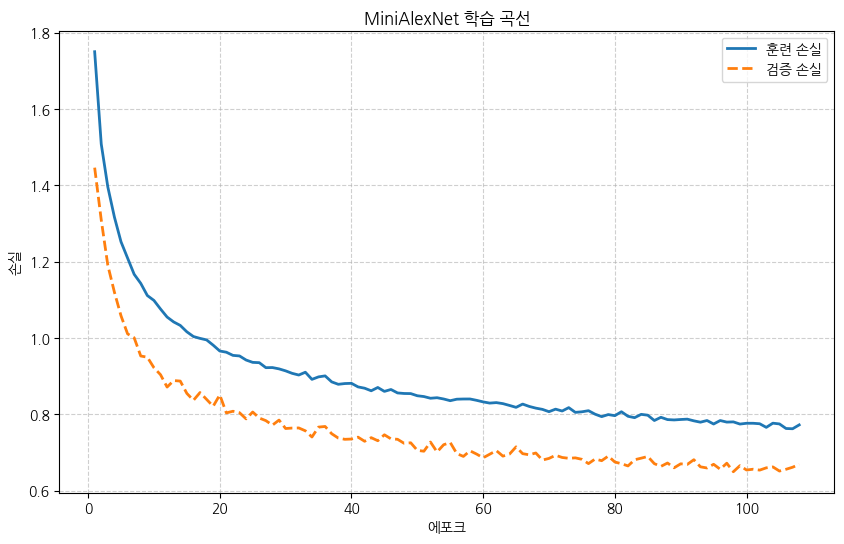

In [11]:
# 참고 - MiniAlexNet 모델 학습
import torch.optim as optim

# 모델마다 결과 재현을 위해 학습 전에 시드 고정
common.set_seed(SEED, deterministic=True)

# MiniAlexNet 모델 객체를 생성하고 학습 장치로 이동
model_alex = MiniAlexNet()
model_alex.to(device)                               

# 옵티마이저
optimizer = optim.Adam(model_alex.parameters(), lr=LR)

# 모델 학습
print('MiniAlexNet 학습')
log_alex = train_with_early_stopping(
    model_alex, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device
)

log_alex.plot(title='MiniAlexNet 학습 곡선', y_label='손실')



In [17]:
# 참고 - MiniAlexNet 모델의 평가

train_loss, train_acc = evaluate(model_alex, train_evaluate_loader, criterion, device)
test_loss, test_acc = evaluate(model_alex, test_loader, criterion, device)
print('MiniAlexNet 모델 평가(훈련 데이터셋)')
print(f'훈련 손실: {train_loss:.4f}, 정확도: {train_acc * 100:.2f}%')
print(f'MiniAlexNet 모델 평가(평가 데이터셋)')
print(f'평가 손실: {test_loss:.4f}, 정확도: {test_acc * 100:.2f}%')

MiniAlexNet 모델 평가(훈련 데이터셋)
훈련 손실: 0.5284, 정확도: 81.61%
MiniAlexNet 모델 평가(평가 데이터셋)
평가 손실: 0.6556, 정확도: 77.55%


MiniVGGNet 학습
  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.9364       1.5717       40.30%     0:11
  2/200       1.5503       1.3069       51.74%     0:22
  3/200       1.3568       1.1654       57.66%     0:32
  4/200       1.2343       1.0359       61.98%     0:43
  5/200       1.1282       0.9585       65.20%     0:54
  6/200       1.0457       0.9680       65.29%     1:05
  7/200       0.9771       0.8389       69.56%     1:16
  8/200       0.9142       0.8283       70.16%     1:27
  9/200       0.8737       0.7759       72.38%     1:38
 10/200       0.8328       0.7614       73.11%     1:49
 11/200       0.8003       0.7278       74.54%     2:00
 12/200       0.7728       0.7144       75.62%     2:11
 13/200       0.7399       0.6597       77.14%     2:21
 14/200       0.7055       0.6284       77.96%     2:33
 15/200       0.6835       0.6537       77.35%     2:43
 16/200       0.6565       0.6413       78.31%     2:54
 17/200       0.6462       0.5980       79.26% 

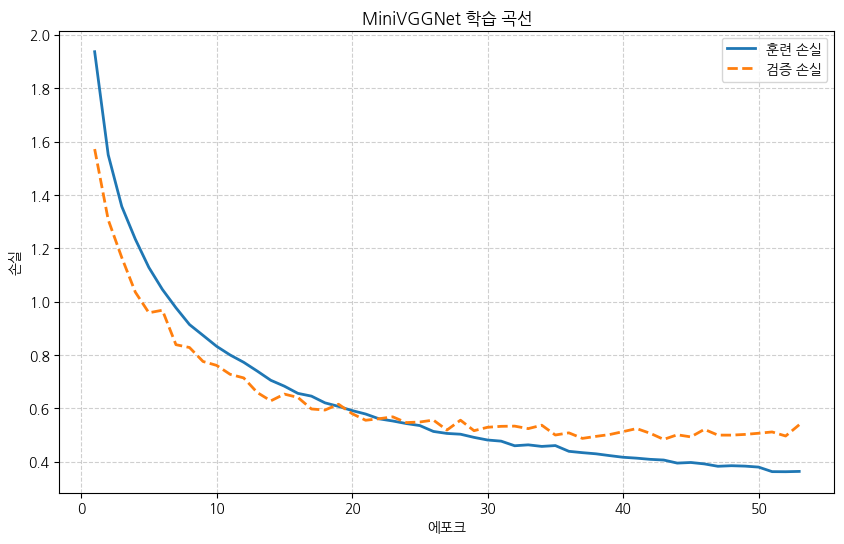

In [13]:
# 참고 - MiniVGGNet 모델 학습

# 모델마다 결과 재현을 위해 학습 전에 시드 고정
common.set_seed(SEED, deterministic=True)

# MiniVGGNet 모델 객체를 생성하고 학습 장치로 이동
model_vgg = MiniVGGNet()
model_vgg.to(device)                               
optimizer = optim.Adam(model_vgg.parameters(), lr=LR)

# 모델 학습
print('MiniVGGNet 학습')
log_vgg = train_with_early_stopping(
    model_vgg, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device
)

log_vgg.plot(title='MiniVGGNet 학습 곡선', y_label='손실')

In [14]:
# 참고 - MiniVGGNet 모델의 평가

train_loss, train_acc = evaluate(model_vgg, train_evaluate_loader, criterion, device)
test_loss, test_acc = evaluate(model_vgg, test_loader, criterion, device)
print('MiniVGGNet 모델 평가(훈련 데이터셋)')
print(f'훈련 손실: {train_loss:.4f}, 정확도: {train_acc * 100:.2f}%')
print(f'MiniVGGNet 모델 평가(평가 데이터셋)')
print(f'평가 손실: {test_loss:.4f}, 정확도: {test_acc * 100:.2f}%')

MiniVGGNet 모델 평가(훈련 데이터셋)
훈련 손실: 0.3000, 정확도: 89.44%
MiniVGGNet 모델 평가(평가 데이터셋)
평가 손실: 0.5311, 정확도: 83.38%


## 정리

- VGGNet 은 3x3 크기의 작은 필터를 반복해 깊게 쌓는 전략으로, 큰 필터 하나가 감당하는 수용 영역을 여러 개의 작은 필터로 대체한다.
- 합성곱 계층을 3배 더 쌓은 MiniVGGNet 의 파라미터 수는 크게 늘지 않는다 ([표 8-1]). 작은 필터로 통일한 효과다.
- 더 깊은 MiniVGGNet 은 더 많은 비선형성을 통과해 특징을 다양하게 조합할 수 있어, 학습 시간은 늘지만 분류 정확도가 개선된다([표 8-2]).

In [15]:
# #---- 추가 테스트 ----#

# class MiniVGGNet_2(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()
#         # 반복되는 VGG 블록을 만드는 헬퍼 함수
#         def vgg_block(in_channels, out_channels):
#             # VGGNet의 핵심 - 3x3 합성곱 두 번 + 풀링으로 축소
#             return nn.Sequential(
#                 nn.Conv2d(
#                     in_channels, out_channels, kernel_size=3, padding=1,
#                 ),
#                 nn.ReLU(),
#                 nn.Conv2d(
#                     out_channels, out_channels, kernel_size=3, padding=1,
#                 ),
#                 nn.ReLU(),
#                 nn.Conv2d(
#                     out_channels, out_channels, kernel_size=3, padding=1,
#                 ),
#                 nn.ReLU(),
#                 nn.MaxPool2d(kernel_size=2, stride=2),
#             )
#         # 특징 추출기 - VGG 블록을 반복해 배치
#         self.features = nn.Sequential(
#             vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
#             vgg_block(32, 64),              # (32, 16, 16) -> (64, 8, 8)
#             vgg_block(64, 128),             # (64, 8, 8)   -> (128, 4, 4)
#         )
#         # 분류기 - 특징을 사용해 분류
#         self.classifier = nn.Sequential(
#             nn.Flatten(),                   # (128, 4, 4) -> (128 * 4 * 4,)
#             nn.Linear(128 * 4 * 4, 128),    # -> (128,)
#             nn.ReLU(),
#             nn.Dropout(p=0.5),              # 50% 확률로 출력을 0으로
#             nn.Linear(128, num_classes),    # (128,) -> (10,)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.classifier(x)
#         return x
    

# class MiniVGGNet_3(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()
#         # 반복되는 VGG 블록을 만드는 헬퍼 함수
#         def vgg_block(in_channels, out_channels):
#             # VGGNet의 핵심 - 3x3 합성곱 두 번 + 풀링으로 축소
#             return nn.Sequential(
#                 nn.Conv2d(
#                     in_channels, out_channels, kernel_size=3, padding=1,
#                 ),
#                 nn.ReLU(),
#                 nn.Conv2d(
#                     out_channels, out_channels, kernel_size=3, padding=1,
#                 ),
#                 nn.ReLU(),
#                 nn.MaxPool2d(kernel_size=2, stride=2),
#             )
#         # 특징 추출기 - VGG 블록을 반복해 배치
#         self.features = nn.Sequential(
#             vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
#             vgg_block(32, 64),              # (32, 16, 16) -> (64, 8, 8)
#             vgg_block(64, 128),             # (64, 8, 8)   -> (128, 4, 4)
#             vgg_block(128, 256),             # (128, 4, 4) -> (256, 2, 2)
#         )
#         # 분류기 - 특징을 사용해 분류
#         self.classifier = nn.Sequential(
#             nn.Flatten(),                   # (256, 2, 2) -> (256 * 2 * 2,)
#             nn.Linear(256 * 2 * 2, 128),    # -> (128,)
#             nn.ReLU(),
#             nn.Dropout(p=0.5),              # 50% 확률로 출력을 0으로
#             nn.Linear(128, num_classes),    # (128,) -> (10,)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.classifier(x)
#         return x
    
# # MiniVGGNet_2 학습
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)
# model_vgg_2 = MiniVGGNet_2()
# model_vgg_2.to(device)
# optimizer = optim.Adam(model_vgg_2.parameters(), lr=LR)
# print('=== MiniVGGNet_2 학습 ===')
# log_vgg_2 = train_with_early_stopping(
#     model_vgg_2, train_loader, valid_loader, criterion, optimizer,
#     EPOCHS, PATIENCE, device,
# )
# log_vgg_2.plot(title='MiniVGGNet_2 학습 곡선', y_label='손실')
# result_vgg_2 = collect_result('MiniVGGNet_2', model_vgg_2, log_vgg_2)
# # MiniVGGNet_3 학습
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)
# model_vgg_3 = MiniVGGNet_3()
# model_vgg_3.to(device)
# optimizer = optim.Adam(model_vgg_3.parameters(), lr=LR)
# print('=== MiniVGGNet_3 학습 ===')
# log_vgg_3 = train_with_early_stopping(
#     model_vgg_3, train_loader, valid_loader, criterion, optimizer,
#     EPOCHS, PATIENCE, device,
# )
# log_vgg_3.plot(title='MiniVGGNet_3 학습 곡선', y_label='손실')
# result_vgg_3 = collect_result('MiniVGGNet_3', model_vgg_3, log_vgg_3)
# # 결과 정리
# print_result_table([result_alex, result_vgg, result_vgg_2, result_vgg_3])


In [16]:
# # 참고 - [표 8-2] 결과 정리
# def print_result_table(results, label_width=12):
#     header = (f'{"모델":>{label_width}s} | {"최적":>4s} | '
#              f'{"전체(초)":>8s} | {"에포크당":>8s} | '
#              f'{"훈련손실":>8s} | {"검증손실":>8s} | '
#              f'{"훈련%":>6s} | {"평가%":>6s}')
#     print(header)
#     print('-' * len(header))
#     for r in results:
#         print(f'{r["name"]:>{label_width}s} | {r["best_epoch"]:>4d} | '
#               f'{r["elapsed"]:>8.1f} | {r["seconds_per_epoch"]:>8.1f} | '
#               f'{r["train_loss"]:>8.4f} | {r["valid_loss"]:>8.4f} | '
#               f'{r["train_acc"]:>5.2f}% | {r["test_acc"]:>5.2f}%')


# print_result_table([result_vgg_2, result_vgg_3])
